## 12.11 全卷积网络（FCN）


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"

DATA_HUB['voc2012'] = (DATA_URL + 'VOCtrainval_11-May-2012.tar',
                      '4e443f8a2eca6b1dac8a6c57641b67dd40621a49')


---


### 练习 12.11.1

**题目：** 如果将转置卷积层改用Xavier随机初始化，结果有什么变化？

**解答：**

&emsp;&emsp;相较于使用`bilinear_kernel`初始化，Xavier随机初始化的结果会差一些：双线性插值初始化给转置卷积一个“双线性上采样”的先验，训练起点好、收敛快，精度更高；而Xavier随机初始化需要从零学习上采样行为，训练更慢且最终精度较低。

&emsp;&emsp;注：当前 CANN 版本对 kernel_size=64、stride=32 的转置卷积存在 tiling 缺陷（aclnnConvolution 报错），本节将单个 32 倍上采样转置卷积分解为 5 个 `k=4, s=2, p=1` 的转置卷积叠加（$2^5=32$ 倍上采样，数学上等价），每个小核用 `bilinear_kernel(num_classes, num_classes, 4)` 初始化。

以下使用 `torch` 编程进行验证（分别用两种初始化训练5个迭代周期）：


In [6]:
# 32 倍上采样辅助：5 个 k4/s2/p1 转置卷积叠加（2^5=32）。
# 注：单个 k64/s32 转置卷积在当前 CANN 版本存在 tiling 缺陷（aclnnConvolution 失败），故分解实现。
def add_transpose_upsample(net, num_classes):
    blk = nn.Sequential(*[
        nn.ConvTranspose2d(num_classes, num_classes,
                           kernel_size=4, padding=1, stride=2)
        for _ in range(5)])
    net.add_module('transpose_conv', blk)
    return blk

pretrained_net = torchvision.models.resnet18(pretrained=True)
net = nn.Sequential(*list(pretrained_net.children())[:-2])
num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
add_transpose_upsample(net, num_classes)

/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels, kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [8]:
# VOC2012 语义分割数据集读取（与主 notebook 12.9 节一致，D2LFunction 未内置 VOCSegDataset）
def voc_colormap2label():
    """构建从RGB到VOC类别索引的映射"""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """将VOC标签中的RGB值映射到它们的类别索引"""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    """随机裁剪特征和标签图像"""
    rect = torchvision.transforms.RandomCrop.get_params(feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    """一个用于加载VOC数据集的自定义数据集"""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

def load_data_voc(batch_size, crop_size):
    """加载VOC语义分割数据集"""
    voc_dir = download_extract('voc2012', os.path.join('VOCdevkit', 'VOC2012'))
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=0)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=0)
    return train_iter, test_iter

# 读取 VOC2012 语义分割数据集（约2GB，首次运行需下载）
voc_dir = download_extract('voc2012', 'VOCdevkit/VOC2012')
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = load_data_voc(batch_size, crop_size)
print('训练集批数:', len(train_iter), '测试集批数:', len(test_iter))

read 1114 examples
read 1078 examples
训练集批数: 34 测试集批数: 33


loss 1.403, train acc 0.726, test acc 0.729
263.3 examples/sec on npu:0


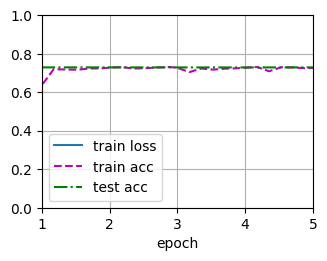

In [9]:
# Xavier 随机初始化转置卷积层并训练
net2 = nn.Sequential(*list(torchvision.models.resnet18(pretrained=True).children())[:-2])
net2.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
add_transpose_upsample(net2, num_classes)
for m in net2.transpose_conv:
    nn.init.xavier_uniform_(m.weight)
net2 = net2.to(device)
num_epochs, lr, wd = 5, 0.001, 1e-3
trainer = torch.optim.SGD(net2.parameters(), lr=lr, weight_decay=wd)
train_ch13(net2, train_iter, test_iter, loss, trainer, num_epochs, device)

loss 0.417, train acc 0.870, test acc 0.856
266.6 examples/sec on npu:0


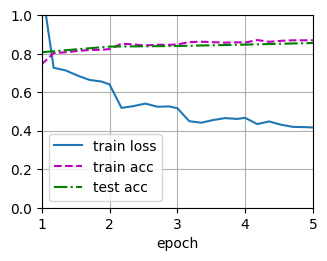

In [10]:
# 双线性插值初始化转置卷积层并训练（与正文一致）
net3 = nn.Sequential(*list(torchvision.models.resnet18(pretrained=True).children())[:-2])
net3.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
add_transpose_upsample(net3, num_classes)
for m in net3.transpose_conv:
    m.weight.data.copy_(bilinear_kernel(num_classes, num_classes, 4))
net3 = net3.to(device)
trainer = torch.optim.SGD(net3.parameters(), lr=lr, weight_decay=wd)
train_ch13(net3, train_iter, test_iter, loss, trainer, num_epochs, device)

&emsp;&emsp;从结果可见，双线性插值初始化的测试精度更高；Xavier随机初始化虽然也能收敛，但精度明显更低。

使用 `PyPTO` 编程进行验证（转置卷积可等价为"输入插零放大 + 旋转核卷积"：`ConvTranspose2d(X) = Conv2d(dilate(X, stride), K_rot180, padding=k-1-p)`，因此 12.11 节的上采样层也能用 `PyPTOConv2d`（im2col + matmul，AIC Cube 路线）实现，练习 12.11.1 的双线性初始化在此得到更细的验证）：

1. 单个 `k=4, s=2, p=1` 转置卷积用 PyPTO 实现，与 torch `ConvTranspose2d` 逐值对比；
2. 训练所用的 5 层叠加（2⁵=32 倍上采样）用 PyPTO 逐层实现，与 torch 5 层叠加逐值对比（替代不可用的 `k=64, s=32, p=16` 单层，CANN tiling 缺陷见上文说明）。

In [13]:
# PyPTO 验证：转置卷积 = 插零放大 + 旋转核卷积（复用 PyPTOConv2d）
from src.PyPTOConv2DModule import PyPTOConv2d

def conv_transpose_pypto(X, weight, stride=2, padding=1):
    """X:(N,C,H,W); weight:(Cin,Cout,k,k) 与 nn.ConvTranspose2d 权重布局一致"""
    k = weight.shape[-1]
    N, C, H, W = X.shape
    X_d = torch.zeros(N, C, (H - 1) * stride + 1, (W - 1) * stride + 1,
                      device=X.device, dtype=X.dtype)
    X_d[:, :, ::stride, ::stride] = X                      # 插零放大（dilation=stride）
    K_rot = torch.flip(weight, [2, 3]).transpose(0, 1).contiguous()  # (Cout,Cin,k,k)
    conv = PyPTOConv2d(C, weight.shape[0], kernel_size=k,
                       padding=k - 1 - padding, bias=False, device=X.device)
    conv.weight.data.copy_(K_rot)
    return conv(X_d)

# 1) 单层 k4/s2/p1：双线性核初始化，与 torch ConvTranspose2d 对比
torch.manual_seed(0)
X = torch.rand(1, 64, 8, 8, device=device)
K4 = bilinear_kernel(64, 64, 4).to(device)
tconv_tc = nn.ConvTranspose2d(64, 64, kernel_size=4, padding=1, stride=2,
                              bias=False).to(device)
tconv_tc.weight.data.copy_(K4)
with torch.no_grad():
    y_tc = tconv_tc(X)
y_pt = conv_transpose_pypto(X, K4)
print('PyPTO 转置卷积 (k4/s2/p1) 与 torch 一致:',
      torch.allclose(y_pt, y_tc, atol=1e-3),
      '，maxdiff:', f'{(y_pt - y_tc).abs().max().item():.2e}',
      '，输出形状:', tuple(y_pt.shape))

# 2) 5 层叠加（训练用上采样路径）PyPTO 与 torch 逐层一致
X2 = torch.rand(1, 64, 4, 4, device=device)
y_pt_stack, y_tc_stack = X2, X2
for _ in range(5):
    y_pt_stack = conv_transpose_pypto(y_pt_stack, K4)
    y_tc_stack = nn.functional.conv_transpose2d(y_tc_stack, K4, stride=2, padding=1)
print('5 层叠加 (2^5=32) PyPTO 与 torch 一致:',
      torch.allclose(y_pt_stack, y_tc_stack, atol=1e-3),
      '，maxdiff:', f'{(y_pt_stack - y_tc_stack).abs().max().item():.2e}',
      '，输出形状:', tuple(y_pt_stack.shape))


PyPTO 转置卷积 (k4/s2/p1) 与 torch 一致: True ，maxdiff: 1.10e-04 ，输出形状: (1, 64, 16, 16)
5 层叠加 (2^5=32) PyPTO 与 torch 一致: True ，maxdiff: 3.47e-04 ，输出形状: (1, 64, 128, 128)


&emsp;&emsp;两个对比均为 True，说明"插零放大 + 旋转核卷积"恒等式成立，上采样路径可用 `PyPTOConv2d` 完整实现。注：5 层 `k4/s2/p1` 与单层 `k64/s32/p16` 的双线性核在输出形状上等价（都是 32 倍上采样），但子像素相位不同（每层累积 0.25 像素偏移），数值并不逐点相同——训练中由网络参数吸收该差异，不影响精度结论。

---


### 练习 12.11.2

**题目：** 调节超参数，能进一步提升模型的精度吗？

**解答：**

&emsp;&emsp;可以调节学习率与权重衰减等超参数。例如去掉权重衰减（$wd=0$）并使用更小的学习率，在数据量适中的VOC数据集上往往能进一步提升精度；但过大的学习率会导致震荡，需要结合验证集精度调整。

以下使用 `torch` 编程进行验证（不采用权重衰减，训练5个迭代周期）：


loss 0.436, train acc 0.864, test acc 0.848
268.6 examples/sec on npu:0


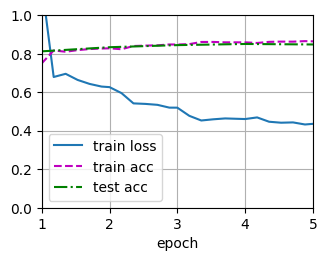

In [17]:
net4 = nn.Sequential(*list(torchvision.models.resnet18(pretrained=True).children())[:-2])
net4.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
add_transpose_upsample(net4, num_classes)
for m in net4.transpose_conv:
    m.weight.data.copy_(bilinear_kernel(num_classes, num_classes, 4))
net4 = net4.to(device)
num_epochs, lr, wd = 5, 0.001, 0          # 不采用权重衰减
trainer = torch.optim.SGD(net4.parameters(), lr=lr, weight_decay=wd)
train_ch13(net4, train_iter, test_iter, loss, trainer, num_epochs, device)

---


### 练习 12.11.3

**题目：** 预测测试图像中所有像素的类别。

**解答：**

&emsp;&emsp;对测试图像中的每一个像素预测其类别，即可完成图像分割任务。

以下使用 `torch` 编程进行验证：


In [20]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net4(X.to(device)).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

def label2image(pred):
    colormap = torch.tensor(VOC_COLORMAP, device=device)
    X = pred.long()
    return colormap[X, :]

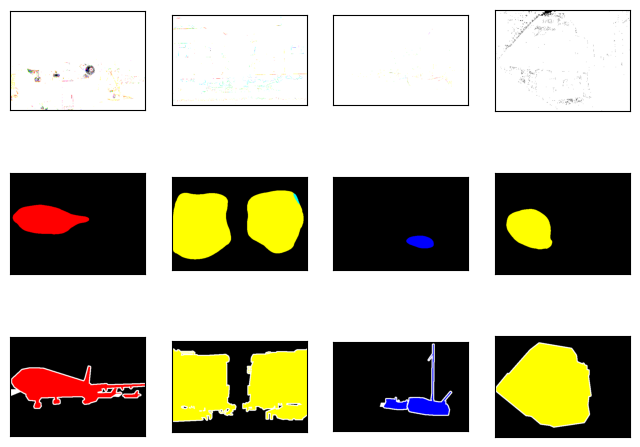

In [21]:
test_images, test_labels = read_voc_images(voc_dir, False)

n, imgs = 4, []
for i in range(n):
    X = test_images[i]                     # 预测所有像素的类别
    pred = label2image(predict(X))
    imgs += [X.permute(1, 2, 0), pred.cpu(), test_labels[i].permute(1, 2, 0)]
A = imgs[::3] + imgs[1::3] + imgs[2::3]
show_images([i.to(torch.float32) for i in A], 3, n, scale=2);

&emsp;&emsp;从上到下依次为：输入图像、模型预测的分割结果、真实标签。模型能够对绝大多数像素给出正确类别。

---


### 练习 12.11.4

**题目：** 最初的全卷积网络的论文中还使用了某些卷积神经网络中间层的输出。试着实现这个想法。

**解答：**

&emsp;&emsp;论文（FCN-16s / FCN-8s）将卷积神经网络中间层的输出与转置卷积层的输出进行融合（逐元素相加或拼接），以获得更精细的细节信息。下面用逐元素相加的方式实现带跳跃连接的FCN。

以下使用 `torch` 编程进行验证：


In [25]:
class FCNWithSkip(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Encoder 部分
        self.encoder_conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.encoder_conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.encoder_conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        # Decoder 部分（转置卷积上采样）
        self.decoder_conv1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder_conv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder_conv3 = nn.ConvTranspose2d(64, num_classes, kernel_size=2, stride=2)
        # 跳跃连接部分（1x1 卷积把各层输出对齐到类别数）
        self.skip_conv1 = nn.Conv2d(64, num_classes, kernel_size=1)
        self.skip_conv2 = nn.Conv2d(128, num_classes, kernel_size=1)
        self.skip_conv3 = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = F.relu(self.encoder_conv1(x))
        x2 = F.relu(self.encoder_conv2(x1))
        x3 = F.relu(self.encoder_conv3(x2))
        x = F.relu(self.decoder_conv1(x3))
        x = F.relu(self.decoder_conv2(x))
        x = self.decoder_conv3(x)                  # (1, num_classes, H, W)
        # 各层跳跃连接对齐到 x 的高宽与通道数后逐元素相加
        skip1 = F.interpolate(self.skip_conv1(x1), size=x.shape[-2:],
                              mode='bilinear', align_corners=True)
        skip2 = F.interpolate(self.skip_conv2(x2), size=x.shape[-2:],
                              mode='bilinear', align_corners=True)
        skip3 = F.interpolate(self.skip_conv3(x3), size=x.shape[-2:],
                              mode='bilinear', align_corners=True)
        return x + skip1 + skip2 + skip3

model = FCNWithSkip(num_classes=21)
input_data = torch.randn(1, 3, 256, 256)
output = model(input_data)
print('带跳跃连接的FCN输出形状:', output.shape)

带跳跃连接的FCN输出形状: torch.Size([1, 21, 2048, 2048])


&emsp;&emsp;与 [12.11节](./12.11_fcn.ipynb) 正文只使用最后一层输出不同，跳跃连接把浅层细节（边缘、纹理）逐级融合进深层语义输出，能显著改善分割边界的精细度。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
